In [ ]:
!pip -q install torch numpy pandas tqdm matplotlib

import numpy as np
import pandas as pd
import re
import random
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
from tqdm import tqdm
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

sales_filename = list(uploaded.keys())[0]
sales_df = pd.read_csv(sales_filename)

sales_df.head()


Saving final_fashion_dataset(r1).csv to final_fashion_dataset(r1).csv


,asin,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,...,Month_51,Month_52,Month_53,Month_54,Month_55,Month_56,Month_57,Month_58,Month_59,Month_60
0,1291691480,4,0,0,0,4,4,4,0,4,...,4,5,4,4,0,4,4,0,0,5
1,1940735033,4,4,5,0,8,5,11,5,4,...,0,5,0,0,4,4,0,5,0,0
2,1940967805,5,5,0,5,5,4,4,5,5,...,0,0,4,0,4,4,0,0,5,5
3,1942705034,4,0,4,5,4,5,4,4,5,...,0,4,5,4,5,0,4,4,4,4
4,3293015344,0,4,4,5,5,4,5,4,4,...,4,4,5,4,5,4,4,4,4,5


In [ ]:
sales_df["asin"] = sales_df["asin"].astype(str).str.strip()

month_cols = [c for c in sales_df.columns if re.search(r"month", c, re.IGNORECASE)]
month_cols.sort(key=lambda x: int(re.search(r"\d+", x).group()))

print("Total month cols:", len(month_cols))
print("Example:", month_cols[:5], "...", month_cols[-5:])

for c in month_cols:
    sales_df[c] = pd.to_numeric(sales_df[c], errors="coerce").fillna(0)

demand_sequences = {
    row["asin"]: row[month_cols].values.astype(np.float32)
    for _, row in sales_df.iterrows()
}

asin_keys = list(demand_sequences.keys())
print("Total products (ASIN):", len(asin_keys))


Total month cols: 60
Example: ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5'] ... ['Month_56', 'Month_57', 'Month_58', 'Month_59', 'Month_60']
Total products (ASIN): 177261


In [ ]:
class InventoryEnv:
    """
    Inventory RL env:
    - action 0..5 => order 0,10,20,30,40,50
    - state = [stock, demand, sentiment(0/1/2), customerWeight(1..15)]
    """

    def __init__(self, demand_series,
                 init_stock_low=20,
                 init_stock_high=80,
                 max_order_quantity=50,
                 price=1.0,
                 holding_cost=0.10,
                 stockout_penalty=2.5,
                 seed=42):

        self.demand_series = demand_series
        self.init_stock_low = init_stock_low
        self.init_stock_high = init_stock_high
        self.max_order_quantity = int(max_order_quantity)

        self.price = float(price)
        self.holding_cost = float(holding_cost)
        self.stockout_penalty = float(stockout_penalty)

        self.rng = np.random.default_rng(seed)
        self.reset()

    def reset(self):
        self.t = 0

        # ✅ key improvement: random initial stock
        self.stock = float(self.rng.integers(self.init_stock_low, self.init_stock_high + 1))

        # sentiment (0,1,2)
        self.sentiment = float(self.rng.integers(0, 3))

        # customer weight (1..15)
        self.customer_weight = float(self.rng.integers(1, 16))

        return self._get_state()

    def _get_state(self):
        demand = float(self.demand_series[self.t])
        return np.array([self.stock, demand, self.sentiment, self.customer_weight], dtype=np.float32)

    def step(self, action):
        order_qty = int(action) * 10
        order_qty = min(order_qty, self.max_order_quantity)

        demand = float(self.demand_series[self.t])

        stock_after_order = self.stock + order_qty
        sales = min(stock_after_order, demand)
        stockout = max(0.0, demand - stock_after_order)
        stock_next = stock_after_order - sales

        # ✅ improved reward shaping: stockout heavier than holding
        reward = (sales * self.price) \
                 - (stock_next * self.holding_cost) \
                 - (stockout * self.stockout_penalty * (self.customer_weight / 15.0))

        self.stock = stock_next
        self.t += 1

        done = (self.t >= len(self.demand_series) - 1)
        next_state = self._get_state() if not done else np.zeros(4, dtype=np.float32)

        return next_state, float(reward), done


In [ ]:
class DQN(nn.Module):
    def __init__(self, state_dim=4, action_dim=6):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, x):
        return self.net(x)


In [ ]:
def choose_action(model, state, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(0, 6)

    state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        q_values = model(state_t)
    return int(torch.argmax(q_values, dim=1).item())


def train_step(model, target_model, optimizer, batch, gamma=0.99):
    states, actions, rewards, next_states, dones = batch

    states_t = torch.tensor(states, dtype=torch.float32)
    actions_t = torch.tensor(actions, dtype=torch.int64).unsqueeze(1)
    rewards_t = torch.tensor(rewards, dtype=torch.float32).unsqueeze(1)
    next_states_t = torch.tensor(next_states, dtype=torch.float32)
    dones_t = torch.tensor(dones, dtype=torch.float32).unsqueeze(1)

    q_vals = model(states_t).gather(1, actions_t)

    with torch.no_grad():
        next_q = target_model(next_states_t).max(1, keepdim=True)[0]
        target = rewards_t + gamma * next_q * (1 - dones_t)

    loss = nn.MSELoss()(q_vals, target)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return float(loss.item())


In [ ]:
model = DQN(state_dim=4, action_dim=6)
target_model = DQN(state_dim=4, action_dim=6)
target_model.load_state_dict(model.state_dict())

optimizer = optim.Adam(model.parameters(), lr=1e-3)

replay = deque(maxlen=25000)
batch_size = 64
gamma = 0.99

epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995
target_update_freq = 200

episodes = 1400
rewards_history = []
losses = []

for ep in tqdm(range(episodes)):
    asin = random.choice(asin_keys)
    demand_series = demand_sequences[asin]

    # skip products with no demand
    if np.sum(demand_series) < 1:
        continue

    env = InventoryEnv(demand_series=demand_series)
    state = env.reset()

    total_reward = 0.0
    done = False
    steps = 0

    while not done:
        action = choose_action(model, state, epsilon)
        next_state, reward, done = env.step(action)

        replay.append((state, action, reward, next_state, float(done)))
        state = next_state
        total_reward += reward
        steps += 1

        if len(replay) >= batch_size:
            minibatch = random.sample(replay, batch_size)
            states, actions, rewards, next_states, dones = zip(*minibatch)

            loss = train_step(
                model, target_model, optimizer,
                (np.array(states), np.array(actions), np.array(rewards),
                 np.array(next_states), np.array(dones)),
                gamma=gamma
            )
            losses.append(loss)

        if steps % target_update_freq == 0:
            target_model.load_state_dict(model.state_dict())

    rewards_history.append(total_reward)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

print("✅ Training completed")


100%|██████████| 1400/1400 [03:26<00:00,  6.79it/s]

✅ Training completed


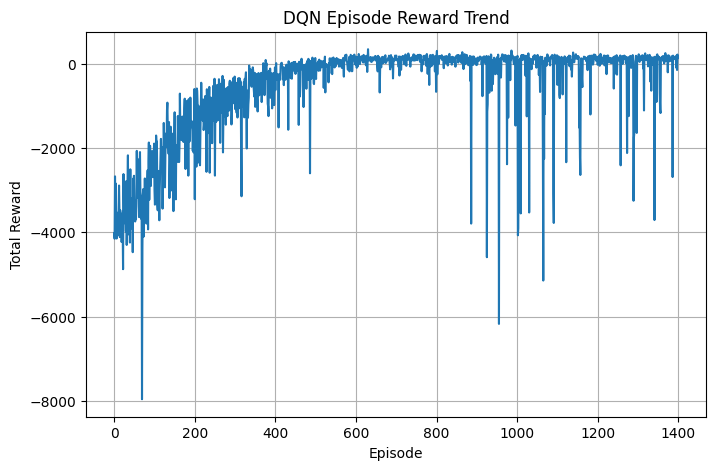

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(rewards_history)
plt.title("DQN Episode Reward Trend")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.show()



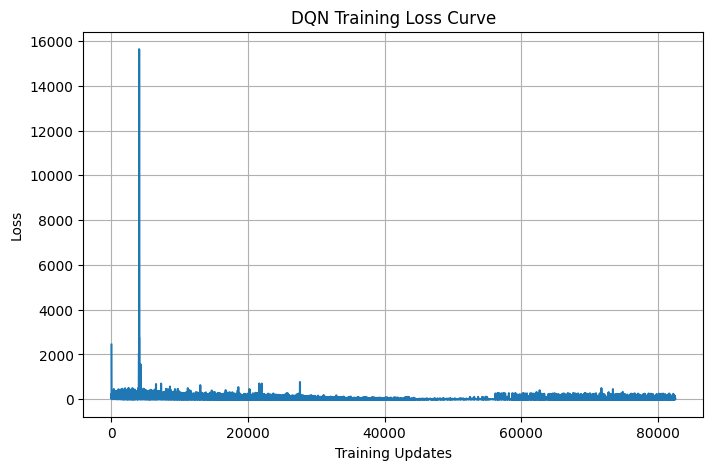

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(losses)
plt.title("DQN Training Loss Curve")
plt.xlabel("Training Updates")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


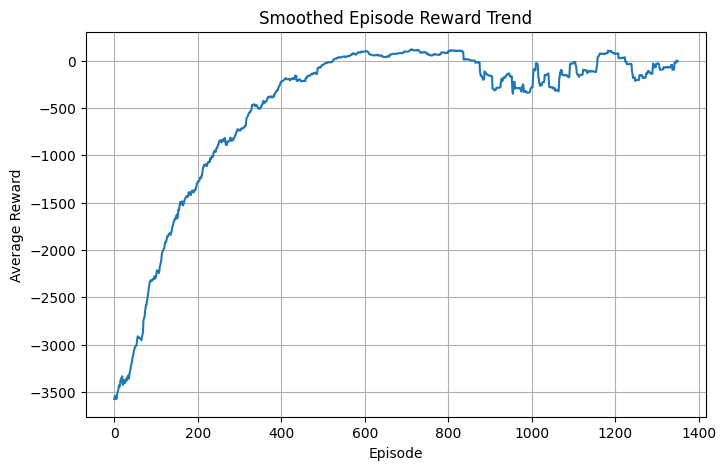

In [ ]:
import numpy as np

window = 50
smoothed_rewards = np.convolve(rewards_history, np.ones(window)/window, mode='valid')

plt.figure(figsize=(8,5))
plt.plot(smoothed_rewards)
plt.title("Smoothed Episode Reward Trend")
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.grid(True)
plt.show()


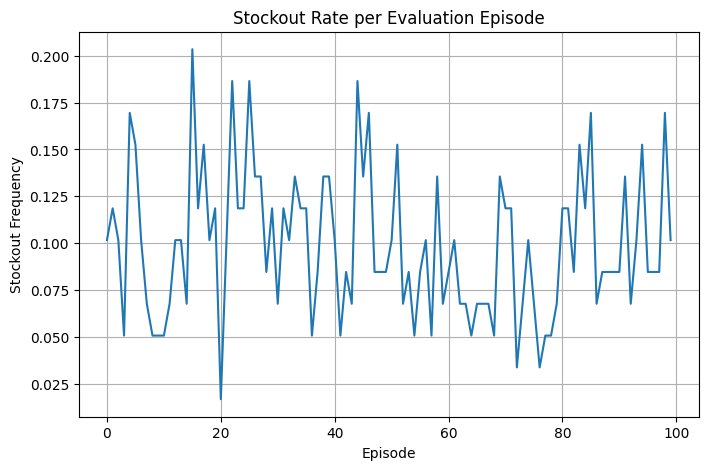

In [ ]:
def evaluate_stockouts(model, episodes=100):
    stockout_rates = []

    for ep in range(episodes):
        asin = random.choice(asin_keys)
        demand_series = demand_sequences[asin]

        if np.sum(demand_series) < 1:
            continue

        env = InventoryEnv(demand_series=demand_series)
        state = env.reset()
        done = False
        stockouts = 0
        steps = 0

        while not done:
            action = choose_action(model, state, epsilon=0.0)  # greedy
            next_state, reward, done = env.step(action)

            # If inventory becomes zero → stockout
            if next_state[0] <= 0:
                stockouts += 1

            state = next_state
            steps += 1

        stockout_rates.append(stockouts / steps)

    return stockout_rates

stockout_rates = evaluate_stockouts(model)

plt.figure(figsize=(8,5))
plt.plot(stockout_rates)
plt.title("Stockout Rate per Evaluation Episode")
plt.xlabel("Episode")
plt.ylabel("Stockout Frequency")
plt.grid(True)
plt.show()


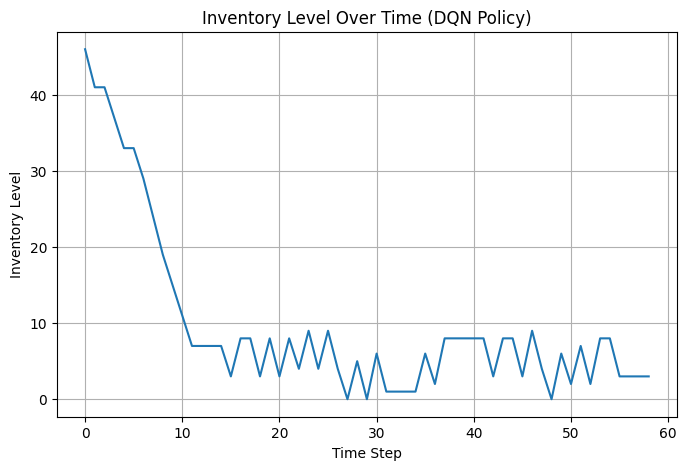

In [ ]:
def inventory_levels_over_time(model):
    asin = random.choice(asin_keys)
    demand_series = demand_sequences[asin]

    env = InventoryEnv(demand_series=demand_series)
    state = env.reset()
    done = False

    inventory_levels = []

    while not done:
        inventory_levels.append(state[0])
        action = choose_action(model, state, epsilon=0.0)
        state, reward, done = env.step(action)

    return inventory_levels

levels = inventory_levels_over_time(model)

plt.figure(figsize=(8,5))
plt.plot(levels)
plt.title("Inventory Level Over Time (DQN Policy)")
plt.xlabel("Time Step")
plt.ylabel("Inventory Level")
plt.grid(True)
plt.show()


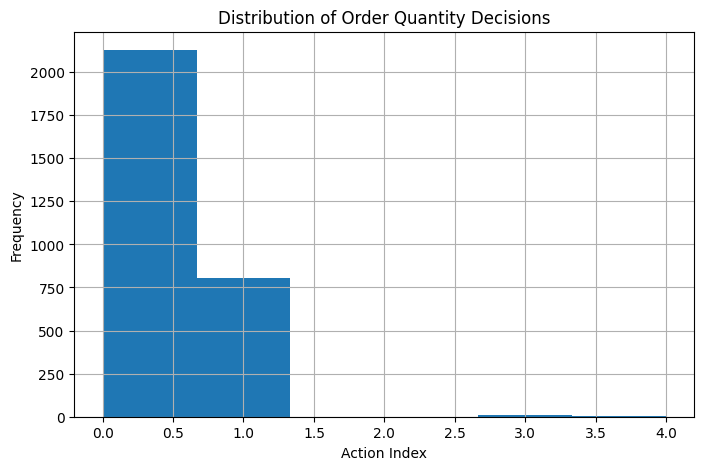

In [ ]:
def action_distribution(model, episodes=50):
    actions_taken = []

    for ep in range(episodes):
        asin = random.choice(asin_keys)
        demand_series = demand_sequences[asin]

        env = InventoryEnv(demand_series=demand_series)
        state = env.reset()
        done = False

        while not done:
            action = choose_action(model, state, epsilon=0.0)
            actions_taken.append(action)
            state, reward, done = env.step(action)

    return actions_taken

actions = action_distribution(model)

plt.figure(figsize=(8,5))
plt.hist(actions, bins=6)
plt.title("Distribution of Order Quantity Decisions")
plt.xlabel("Action Index")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


In [ ]:
# torch.save(model.state_dict(), "inventory_agent1.pth")
# print("✅ Saved: inventory_agent1.pth")

In [ ]:
# from google.colab import files
# files.download("inventory_agent1.pth")
